This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment ACTIVE model to the real, experimental data. Here, we try to only match the first spike with one set of parameters (still without parallelly training different initializations). This notebook is just a preparation for the parallel training, not thoroughly optimized.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

We initialize the NN based on https://arxiv.org/pdf/2311.15890, and with it we get stable u values.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2

from jax import config
config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx


import equinox as eqx
import flax.nnx as nnx


Let's see our data

In [2]:
t_max = 80.0
cut = 1500

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


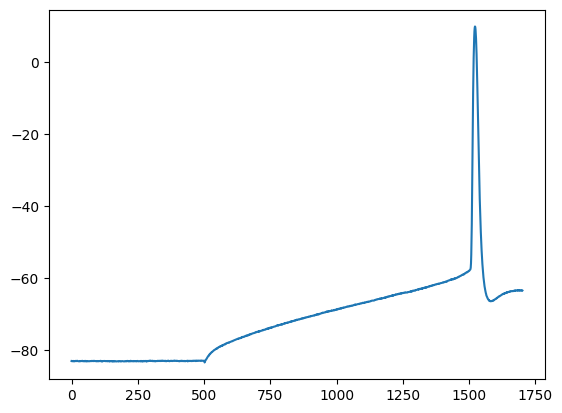

In [3]:
plt.plot(v_data[0])

In [4]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 2

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


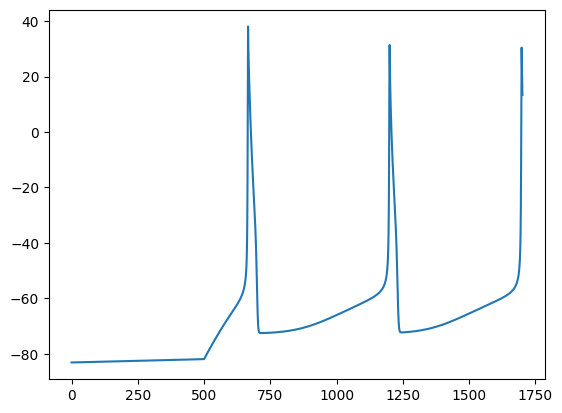

In [5]:
# One random simulation
plt.plot(v_single[0])

**Initialization**

In [6]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices

)

In [8]:
key = jax.random.PRNGKey(0)
dt = 0.025

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   # RK4
    h=dt,
    u_dim=8,
    use_complex=True,
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, "scaled: ", dt*e)

Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) scaled:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) scaled:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) scaled:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) scaled:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) scaled:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) scaled:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) scaled:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) scaled:  (-0.9220778457683627+0.47510614586898203j)


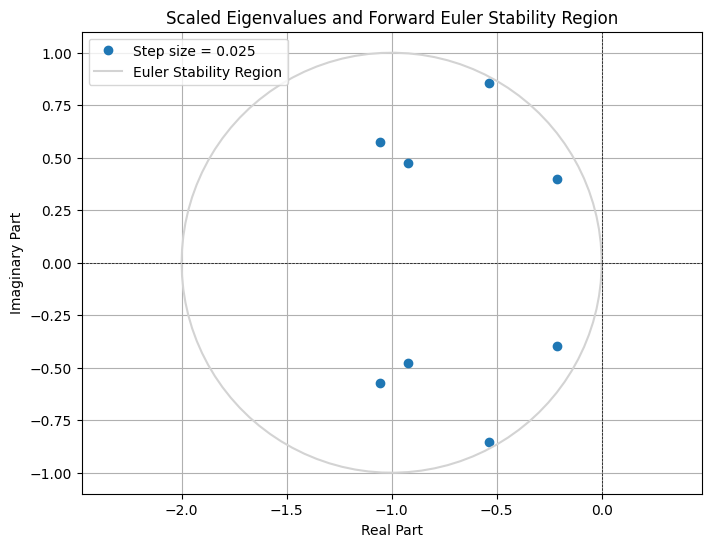

In [9]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

Now we make the Lambda, Pi and W matrices based on the paper

In [10]:
num_layers = 3
layer_shapes = [(9, 32), (32, 16), (16, 8)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

In [11]:
# Checking the eigenvalues of the generated initialization
jnp.linalg.eigvals(W_matrices[2]@W_matrices[1]@W_matrices[0][:, :8])

Array([-42.14161353+22.98417698j, -42.14161353-22.98417698j,
       -21.54550625+34.14736393j, -21.54550625-34.14736393j,
       -36.88311383+19.00424583j, -36.88311383-19.00424583j,
        -8.51603533+15.86861961j,  -8.51603533-15.86861961j],      dtype=complex128)

In [12]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1
@jax.jit
def normalize_voltage_softsign(v):
    return v / (1 + jnp.abs(v))
    

class SimpleNeuralNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, W_matrices: list[jax.Array], epsilon: float = 1e-4):
        self.linear1 = nnx.Linear(u_dimension + 1, 32, rngs=rngs)
        #self.norm1 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear2 = nnx.Linear(32, 16, rngs=rngs)
        #self.norm2 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear3 = nnx.Linear(16, u_dimension, rngs=rngs)

        self.linear1.kernel = nnx.Param(W_matrices[0].T)
        self.linear2.kernel = nnx.Param(W_matrices[1].T)
        self.linear3.kernel= nnx.Param(W_matrices[2].T)

        self.linear1.bias = nnx.Param(jax.random.uniform(rngs(), (32,), minval=-epsilon, maxval=epsilon))
        self.linear2.bias = nnx.Param(jax.random.uniform(rngs(), (16,), minval=-epsilon, maxval=epsilon))
        self.linear3.bias = nnx.Param(jax.random.uniform(rngs(), (u_dimension,), minval=-epsilon, maxval=epsilon))

    def __call__(self, inputs):
        x = self.linear1(inputs)
        x = jax.nn.relu(x)
        # x = 2* jax.nn.sigmoid(x) - 1
        # x = jax.nn.tanh(x)

        x = self.linear2(x)
        x = jax.nn.relu(x)
        # x = 2* jax.nn.sigmoid(x) - 1
        # x = jax.nn.tanh(x)
        return self.linear3(x)

class ReadoutNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension, 32, rngs=rngs)
        self.linear2 = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, u):
        u = self.linear1(u)
        u = jax.nn.relu(u)
        return self.linear2(u)
    
class CorrectionModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, W_matrices: list[jax.Array], epsilon: float = 1e-4):
        self.neural_net = SimpleNeuralNet(rngs=rngs, u_dimension = u_dimension, W_matrices=W_matrices, epsilon = epsilon)
        self.readout_net = ReadoutNet(rngs=rngs, u_dimension = u_dimension)

        sampled_params = sample_prior(init_rng_key)
        self.channel_params_normal = nnx.Param(sampled_params)

    def __call__(self, u, v):
        u_new = self.neural_net(jnp.stack([u, v]))
        return self.readout_net(u_new)

In [13]:
dt = 0.025

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff = carry


        #voltage = state["v"][rec_inds].squeeze()
        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage_softsign(voltage)
        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        u_new = u + dt*neural_net(inputs) / u_time_constant #0.02 #0.0008
        add_current = readout_net(u_new).squeeze()
        nn_res = neural_net(inputs)


        total_current = current[t] + add_current * added_curr_std #/300 #10
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]


        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(nn_res)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), _ = final_carry

    return recs, adds, us, nn_reses

In [14]:
from voltage_fitting.loss_util import (
    get_scaled_loss,
)

cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr=300, reg_strength=0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds, additional_currents, us, nn_reses = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    # sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    # reg_loss = reg_strength * jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))

    # total_loss = sse_loss + reg_loss

    scaled_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)
    return scaled_loss

In [25]:
rngs = nnx.Rngs(1)

u_dimension = 8
np.random.seed(42)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4
model = CorrectionModel(rngs = rngs, u_dimension = u_dimension,  W_matrices = W_matrices, epsilon = epsilon)

all_setup = set_setup(setup)



added_curr_std = 1.0/10.0
u_time_constant = 100

thr = None


initial_lr = 12e-4 # 2e-1 for lbfgs?
decay_factor = 1 # 0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400  # after x epochs, stop decaying
decay_start = 200 
decay_end = 350

# Normal exponential decay schedule
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

# Wrapped schedule that stops decaying after decay_until
# def clipped_schedule(step):
#     clipped_step = jnp.minimum(step, decay_until)
#     return raw_schedule(clipped_step)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

optimizer = optax.adam(learning_rate=custom_schedule)

# Other optimizers tried:
# optimizer = optax.sgd(learning_rate=clipped_schedule, momentum = 0.7)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1e6),  # Clip gradients
#     optax.sgd(learning_rate=clipped_schedule, momentum=0.5)
# )

# optimizer = optax.chain(
#     optax.scale_by_lbfgs(memory_size = 8), #6
#     optax.scale(-initial_lr),
# )

optimizer_state = nnx.Optimizer(model, optimizer)



def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, u_time_constant, thr)
        return loss


num_epochs = 400
losses = []

grad_fn = nnx.jit(nnx.value_and_grad(simulation_loss_fn))

In [26]:
for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    
    #cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak']) #Multi-comp
    cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()


    


    loss, grads = grad_fn(optimizer_state.model)
    optimizer_state.update(grads)


    # inter_ts, inter_us, inter_preds, inter_additional_currents = simulate_full_trace(
    # model.neural_net,
    # model.readout_net,
    # initial_state,
    # step_fn,
    # current,
    # time_vec,
    # u_init
    # )
    

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
        # print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")
        # print(f"Min u: {jnp.min(inter_us)}, max u: {jnp.max(inter_us)}")
        # print(f"Min tnn: {jnp.min(inter_ts)}, max tnn: {jnp.max(inter_ts)}")
        # print("")

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Loss: 203.496663
Epoch 10, Loss: 180.628638
Epoch 20, Loss: 180.081785
Epoch 30, Loss: 177.258034
Epoch 40, Loss: 171.086582
Epoch 50, Loss: 163.872930
Epoch 60, Loss: 166.328849
Epoch 70, Loss: 144.216091
Epoch 80, Loss: 198.997440
Epoch 90, Loss: 150.591647
Epoch 100, Loss: 137.262394
Epoch 110, Loss: 137.731286
Epoch 120, Loss: 142.771136
Epoch 130, Loss: 153.581221
Epoch 140, Loss: 152.535483
Epoch 150, Loss: 149.989203
Epoch 160, Loss: 138.512339
Epoch 170, Loss: 126.613319
Epoch 180, Loss: 130.592112
Epoch 190, Loss: 139.589755
Epoch 200, Loss: 133.414513
Epoch 210, Loss: 118.441971
Epoch 220, Loss: 138.816388
Epoch 230, Loss: 146.839817
Epoch 240, Loss: 150.558926
Epoch 250, Loss: 168.763874
Epoch 260, Loss: 165.598705
Epoch 270, Loss: 127.606271
Epoch 280, Loss: 136.784241
Epoch 290, Loss: 134.224292
Epoch 300, Loss: 165.240523
Epoch 310, Loss: 189.554817
Epoch 320, Loss: 192.267939
Epoch 330, Loss: 120.322639
Epoch 340, Loss: 147.397465
Epoch 350, Loss: 148.949270
Epo

In [27]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, u_time_constant, thr
)


final_sse_loss = jnp.sum((final_preds.squeeze() - v_data.squeeze())**2)
final_reg_loss = jnp.sum(final_additional_currents)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


Text(0.5, 1.0, 'Dynamics Network Outputs')

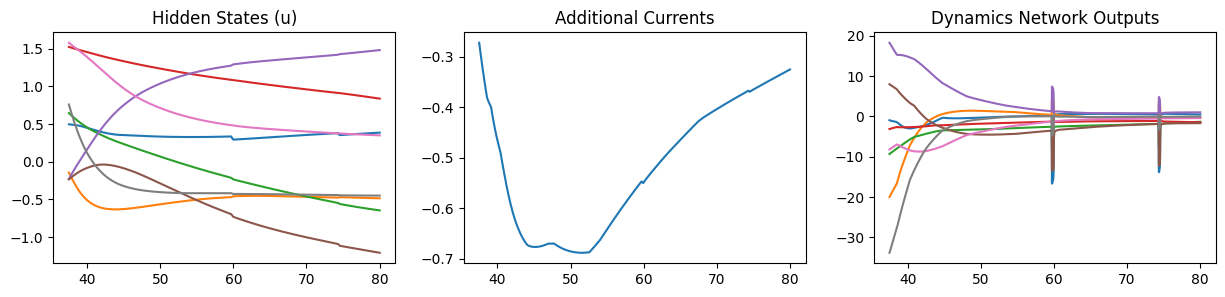

In [28]:
fig, axs = plt.subplots(1,3, figsize = (15,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Hidden States (u)")
axs[1].plot(time_vec, final_additional_currents)
axs[1].set_title("Additional Currents")
axs[2].plot(time_vec, final_nn_reses)
axs[2].set_title("Dynamics Network Outputs")

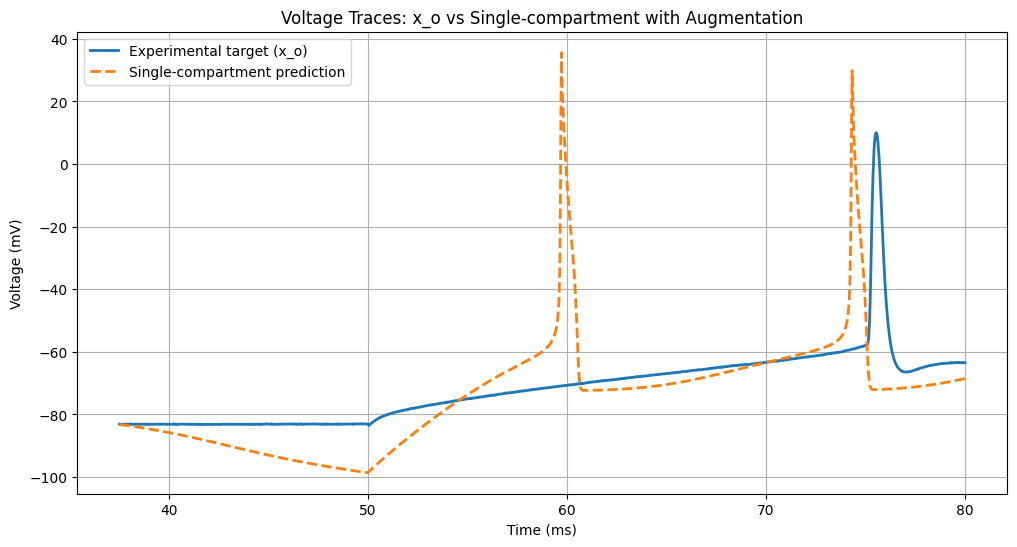

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec, v_data[0], label="Experimental target (x_o)", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: x_o vs Single-compartment with Augmentation")
plt.grid()

plt.show()